# EDA on Google Play Store Apps

> **Author:** Waseem Ahmed &nbsp;|&nbsp; **Environment:** `pandas_env` (Python 3.11) &nbsp;|&nbsp; **Tools:** pandas · numpy · seaborn · matplotlib

---

## Project Overview

This notebook performs an **Exploratory Data Analysis (EDA)** on the Google Play Store Apps dataset. The goal is to uncover patterns and insights that could help app developers, product managers, and marketers understand what makes an Android app successful on the Play Store.

### Objectives
- Understand the structure and quality of the dataset
- Clean and preprocess messy real-world data
- Analyze distributions of key features (ratings, installs, categories, pricing)
- Discover relationships between features — what correlates with higher ratings or more installs?
- Extract actionable insights for app developers targeting the Android market


## **About the Dataset**

**Source:** [Google Play Store Apps — Kaggle](https://www.kaggle.com/lava18/google-play-store-apps)  
**Citation:** L. Gupta, *"Google Play Store Apps"*, Feb 2019. \[Online\]. Available: https://www.kaggle.com/lava18/google-play-store-apps

### Context
While many public datasets provide Apple App Store data, counterpart datasets for the Google Play Store are rare. The Play Store uses dynamic page loading (jQuery-based), making scraping more technically challenging than iTunes. This dataset was carefully scraped and compiled to fill that gap.

### Content
The dataset contains **10,841 apps** with **13 features** per app:

| Column | Description | Type |
|--------|-------------|------|
| `App` | Name of the application | String |
| `Category` | App category on the Play Store | Categorical |
| `Rating` | Average user rating (0–5) | Float |
| `Reviews` | Number of user reviews | Integer |
| `Size` | App size (e.g. `15M`, `512k`) | String → Float |
| `Installs` | Number of installs (e.g. `1,000,000+`) | String → Integer |
| `Type` | Free or Paid | Categorical |
| `Price` | Price in USD (e.g. `$2.99`) | String → Float |
| `Content Rating` | Target audience (e.g. Everyone, Teen) | Categorical |
| `Genres` | Sub-genre of the app | Categorical |
| `Last Updated` | Date of last update | String → DateTime |
| `Current Ver` | Current app version | String |
| `Android Ver` | Minimum required Android version | String |

### Known Data Quality Issues
- `Rating` contains ~1,474 missing values and an outlier of `19.0`
- `Installs` and `Price` are stored as strings with symbols (`+`, `,`, `$`)
- `Size` mixes units (`M`, `k`) and contains `"Varies with device"`
- One corrupted row where column values are shifted

### Inspiration
Play Store data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to capture the Android market — the world's largest mobile platform.

## Imports & Setup

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ydata_profiling as yd

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

import warnings
warnings.filterwarnings("ignore")

/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

The dataset is stored locally inside the `datasets/` folder of this project directory.

In [2]:
import os

if os.path.exists("/kaggle/input/google-play-store-apps"):
    base_path = "/kaggle/input/google-play-store-apps"
else:
    base_path = "datasets"

df = pd.read_csv(f"{base_path}/googleplaystore.csv")
df_reviews = pd.read_csv(f"{base_path}/googleplaystore_user_reviews.csv")

print(f"Main dataset:    {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Reviews dataset: {df_reviews.shape[0]:,} rows × {df_reviews.shape[1]} columns")

Main dataset:    10,841 rows × 13 columns
Reviews dataset: 64,295 rows × 5 columns


## ydata-Profiling

In [3]:
profile = yd.ProfileReport(df)
profile.to_file(output_file="./outputs/google_play_store_apps_eda.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 42.67it/s]


## **Data Pre-Processing**

In [4]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df.columns.tolist()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [7]:
df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [8]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [9]:
df.sample(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
7179,CD COMET,MAPS_AND_NAVIGATION,4.3,12,2.6M,100+,Free,0,Everyone,Maps & Navigation,"August 4, 2018",4.0,4.1 and up
5569,【Miku AR Camera】Mikuture,FAMILY,4.4,36268,41M,"1,000,000+",Free,0,Teen,Entertainment,"April 25, 2017",3.0.15,4.2 and up
6946,Bx Thailand Alert (Bitcoin),FINANCE,4.7,3,8.2M,100+,Free,0,Everyone,Finance,"February 5, 2018",1.0.2,4.2 and up
7485,CK Call NEW,COMMUNICATION,NaN,0,4.2M,10+,Free,0,Everyone,Communication,"April 26, 2017",3.8.8,2.2 and up
7448,CJ Auto école,FAMILY,NaN,0,12M,50+,Free,0,Everyone,Education,"June 24, 2014",1.0,2.2 and up
5944,Elif Ba Oyunu,TOOLS,3.7,26,2.2M,"5,000+",Free,0,Everyone,Tools,"November 2, 2015",1.1,2.3 and up
10163,EZ Utilities Extension,TOOLS,3.9,33,473k,"5,000+",Free,0,Everyone,Tools,"May 5, 2016",9.0,6.0 and up
623,Geeks Dating,DATING,NaN,0,13M,50+,Free,0,Mature 17+,Dating,"July 10, 2018",1.0,4.1 and up
2428,Exposure Ed,MEDICAL,3.0,2,16M,500+,Free,0,Everyone,Medical,"July 17, 2018",1.2.9,4.4 and up
9987,eCooltra: scooter sharing. Share electric scoo...,TRAVEL_AND_LOCAL,4.2,2822,27M,"100,000+",Free,0,Everyone,Travel & Local,"July 27, 2018",1.21.2,4.1 and up


In [10]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [11]:
df.columns.to_list()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [12]:
df["Size"].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
552k                     1
885k                     1
1020k                    1
582k                     1
619k                     1
Name: count, Length: 462, dtype: int64

### **Check that how many KBs are there in one MB? How to calculate them**

1. Convert KBs into M
2. Then remove M from all rows
3. Handle `varies with device`

In [13]:
df["Installs"].isnull().sum()

np.int64(0)

In [14]:
df["Installs"].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             907
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Free                 1
Name: count, dtype: int64

In [15]:
df["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [16]:
df["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [17]:
df["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [18]:
df["Size"].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
552k                     1
885k                     1
1020k                    1
582k                     1
619k                     1
Name: count, Length: 462, dtype: int64

In [19]:
df["Price"].value_counts()

Price
0           10040
$0.99         148
$2.99         129
$1.99          73
$4.99          72
            ...  
$394.99         1
$1.26           1
Everyone        1
$1.20           1
$1.04           1
Name: count, Length: 93, dtype: int64

In [20]:
df["Price"].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [21]:
df["Price"].isnull().sum()

np.int64(0)

### **`Task:`** Write down all the numeric variables and make them numeric
1. **Size**
2. **Installs**
3. **Price**

In [22]:
df[df["Size"] == "Varies with device"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,Varies with device,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",Varies with device,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057,Varies with device,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211,Varies with device,"5,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
68,REPUVE,AUTO_AND_VEHICLES,3.9,356,Varies with device,"100,000+",Free,0,Everyone,Auto & Vehicles,"May 25, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471,Varies with device,"100,000+",Free,0,Everyone,Weather,"July 24, 2018",Varies with device,Varies with device
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8,Varies with device,"1,000+",Free,0,Everyone,Maps & Navigation,"September 27, 2017",Varies with device,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,Varies with device,"100,000+",Free,0,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,Varies with device,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


In [23]:
def clean_size(size):
    if size == "Varies with device" or pd.isna(size):
        return np.nan
    elif size.endswith("M"):
        return float(size[:-1])          # "15M" → 15.0
    elif size.endswith("k"):
        return float(size[:-1]) / 1024   # "512k" → 0.5 (convert to MB)
    else:
        return np.nan

# Step 1: clean the column
df["Size"] = df["Size"].apply(clean_size)

# Step 2: impute "Varies with device" (now NaN) with median per category
df["Size"] = df.groupby("Category")["Size"].transform(
    lambda x: x.fillna(x.median())
)

print(df["Size"].isnull().sum(), "nulls remaining")
df["Size"].describe()

1 nulls remaining


count    10840.000000
mean        20.322632
std         21.231680
min          0.008301
25%          5.600000
50%         12.000000
75%         27.000000
max        100.000000
Name: Size, dtype: float64

In [24]:
df["Size"].unique()

array([1.90000000e+01, 1.40000000e+01, 8.70000000e+00, 2.50000000e+01,
       2.80000000e+00, 5.60000000e+00, 2.90000000e+01, 3.30000000e+01,
       3.10000000e+00, 2.80000000e+01, 1.20000000e+01, 2.00000000e+01,
       2.10000000e+01, 3.70000000e+01, 2.70000000e+00, 5.50000000e+00,
       1.70000000e+01, 3.90000000e+01, 3.10000000e+01, 4.20000000e+00,
       7.00000000e+00, 2.30000000e+01, 6.00000000e+00, 6.10000000e+00,
       4.60000000e+00, 9.20000000e+00, 5.20000000e+00, 1.10000000e+01,
       2.40000000e+01, 8.95000000e+00, 9.40000000e+00, 1.50000000e+01,
       1.00000000e+01, 1.20000000e+00, 2.60000000e+01, 8.00000000e+00,
       7.90000000e+00, 5.60000000e+01, 5.70000000e+01, 1.60000000e+01,
       3.50000000e+01, 5.40000000e+01, 1.96289062e-01, 3.60000000e+00,
       5.70000000e+00, 8.60000000e+00, 2.40000000e+00, 2.70000000e+01,
       2.50000000e+00, 3.40000000e+00, 8.90000000e+00, 3.90000000e+00,
       2.90000000e+00, 3.80000000e+01, 3.20000000e+01, 5.40000000e+00,
      

In [25]:
df["Installs"].dtype

dtype('O')

In [26]:
bins   = [0, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 1_000_000_000]
labels = ["<100", "100–1K", "1K–10K", "10K–100K", "100K–1M", "1M–10M", "10M+"]

df["Installs_Binned"] = pd.cut(df["Installs"], bins=bins, labels=labels, right=True)

df["Installs_Binned"].value_counts().sort_index()

TypeError: '<' not supported between instances of 'int' and 'str'

In [ ]:
df["Price"].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [ ]:
df["Price"].value_counts()

Price
0           10040
$0.99         148
$2.99         129
$1.99          73
$4.99          72
            ...  
$394.99         1
$1.26           1
Everyone        1
$1.20           1
$1.04           1
Name: count, Length: 93, dtype: int64

In [ ]:
df = df[df["Price"] != "Everyone"]

In [ ]:
df[df["Price"] == "Everyone"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Binned


In [ ]:
df["Rating"].value_counts()

Rating
4.4    1109
4.3    1076
4.5    1038
4.2     952
4.6     823
4.1     708
4.0     568
4.7     499
3.9     386
3.8     303
5.0     274
3.7     239
4.8     234
3.6     174
3.5     163
3.4     128
3.3     102
4.9      87
3.0      83
3.1      69
3.2      64
2.9      45
2.8      42
2.7      25
2.6      25
2.5      21
2.3      20
2.4      19
1.0      16
2.2      14
1.9      13
2.0      12
1.7       8
1.8       8
2.1       8
1.6       4
1.4       3
1.5       3
1.2       1
Name: count, dtype: int64

In [ ]:
df["Rating"].max()

np.float64(5.0)

In [ ]:
df["Price"] = df["Price"].str.replace("$", "", regex=False).astype(float)

In [ ]:
df["Price"].max()

np.float64(400.0)

In [ ]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [ ]:
df["Reviews"].dtype

dtype('int64')

In [ ]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [ ]:
print(df.duplicated().sum())   # check first

483


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   App              10357 non-null  object        
 1   Category         10357 non-null  object        
 2   Rating           8892 non-null   float64       
 3   Reviews          10357 non-null  int64         
 4   Size             10357 non-null  float64       
 5   Installs         10357 non-null  float64       
 6   Type             10356 non-null  object        
 7   Price            10357 non-null  float64       
 8   Content Rating   10357 non-null  object        
 9   Genres           10357 non-null  object        
 10  Last Updated     10357 non-null  datetime64[ns]
 11  Current Ver      10349 non-null  object        
 12  Android Ver      10355 non-null  object        
 13  Installs_Binned  10342 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(

In [ ]:
df.isnull().sum()

App                   0
Category              0
Rating             1465
Reviews               0
Size                  0
Installs              0
Type                  1
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           8
Android Ver           2
Installs_Binned      15
dtype: int64

In [ ]:
df["Type"].value_counts()

Type
Free    9591
Paid     765
Name: count, dtype: int64

In [ ]:
df["Type"] = df["Type"].fillna("Free")

In [ ]:
df["Type"].value_counts()

Type
Free    9592
Paid     765
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   App              10357 non-null  object        
 1   Category         10357 non-null  object        
 2   Rating           8892 non-null   float64       
 3   Reviews          10357 non-null  int64         
 4   Size             10357 non-null  float64       
 5   Installs         10357 non-null  float64       
 6   Type             10357 non-null  object        
 7   Price            10357 non-null  float64       
 8   Content Rating   10357 non-null  object        
 9   Genres           10357 non-null  object        
 10  Last Updated     10357 non-null  datetime64[ns]
 11  Current Ver      10349 non-null  object        
 12  Android Ver      10355 non-null  object        
 13  Installs_Binned  10342 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(

In [ ]:
df.isnull().sum()

App                   0
Category              0
Rating             1465
Reviews               0
Size                  0
Installs              0
Type                  0
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           8
Android Ver           2
Installs_Binned      15
dtype: int64

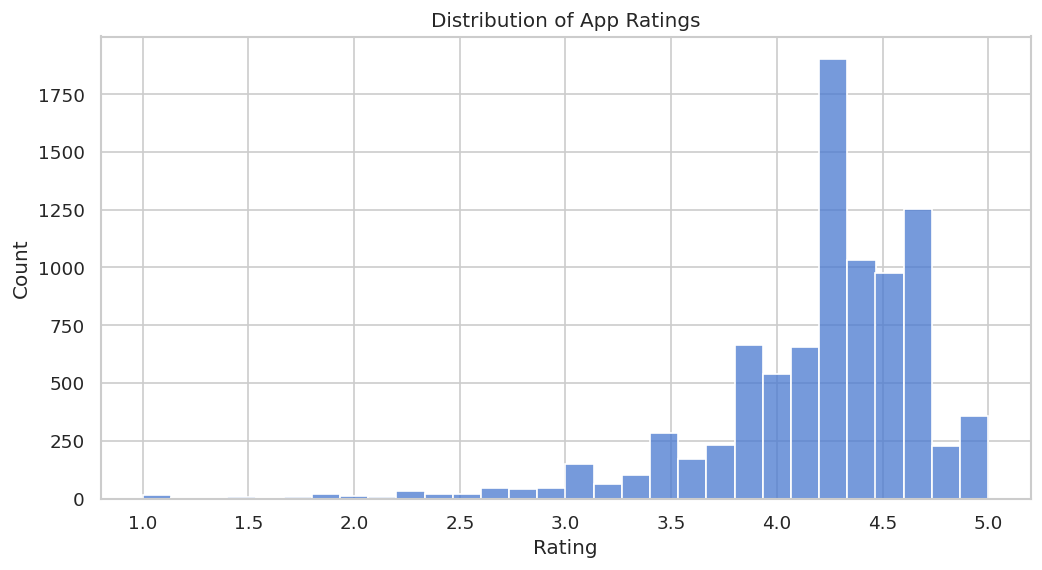

In [ ]:
# 1. Rating distribution
sns.histplot(df["Rating"].dropna(), bins=30)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.show()

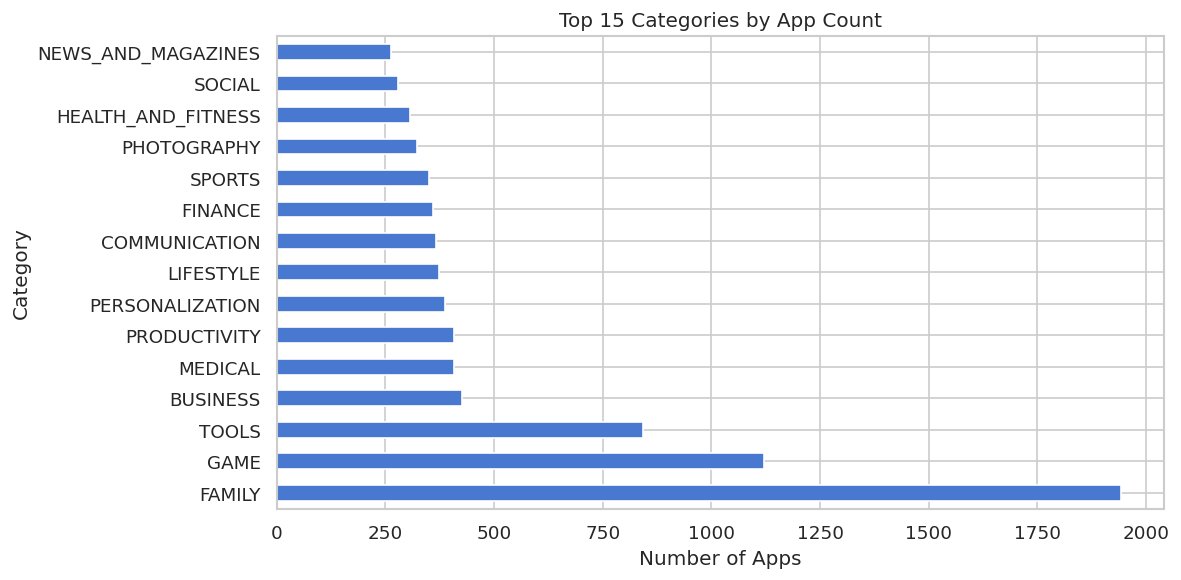

In [ ]:
# 2. Top categories
df["Category"].value_counts().head(15).plot(kind="barh")
plt.title("Top 15 Categories by App Count")
plt.xlabel("Number of Apps")
plt.tight_layout()
plt.show()

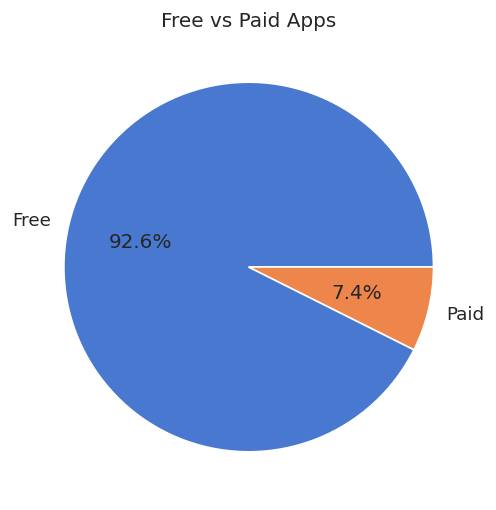

In [ ]:
# 3. Free vs Paid
df["Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.show()

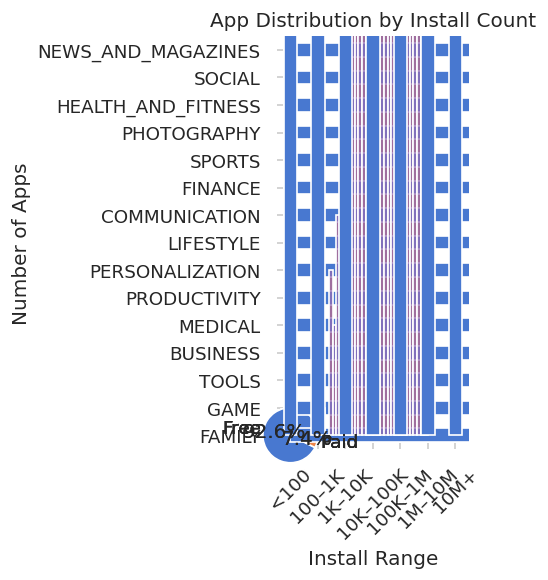

In [ ]:
# 4. Installs distribution
df["Installs_Binned"].value_counts().sort_index().plot(kind="bar")
plt.title("App Distribution by Install Count")
plt.xlabel("Install Range")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()